### Illustration of brain slices using Python

In [1]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pyplot import cm

In [18]:
list(test.columns)

['Unnamed: 0',
 'cell_label',
 'brain_section_label',
 'cluster_alias',
 'average_correlation_score',
 'feature_matrix_label',
 'donor_label',
 'donor_genotype',
 'donor_sex',
 'x',
 'y',
 'z_section',
 'neurotransmitter',
 'class',
 'subclass',
 'supertype',
 'cluster',
 'neurotransmitter_color',
 'class_color',
 'subclass_color',
 'supertype_color',
 'cluster_color',
 'x_reconstructed',
 'y_reconstructed',
 'z_reconstructed',
 'parcellation_index',
 'x_ccf',
 'y_ccf',
 'z_ccf',
 'parcellation_organ',
 'parcellation_category',
 'parcellation_division',
 'parcellation_structure',
 'parcellation_substructure',
 'parcellation_organ_color',
 'parcellation_category_color',
 'parcellation_division_color',
 'parcellation_structure_color',
 'parcellation_substructure_color']

In [15]:
test = pd.read_csv('/data/coro_data.csv',dtype={"cell_label":str})
test.rename(columns={'x_section':'x', 'y_section':'y'}, inplace=True)

In [25]:
sections = ['C57BL6J-638850.59','C57BL6J-638850.60','C57BL6J-638850.61']
filtered = test[test['brain_section_label'].isin(sections)]

In [30]:
subs = filtered['subclass'].unique()
sub1 = [v for v in subs if 'Glut' in v]
sub2 = [v for v in subs if 'Gaba' in v]

In [33]:
filtered = filtered[filtered['subclass'].isin(sub1+sub2)]

In [8]:
def parcellation_cell_count(df,level) :
    cell_count = df.groupby(level)[['average_correlation_score']].count()
    cell_count.columns = ['number_of_cells']
    cell_count.sort_values('number_of_cells',ascending=False,inplace=True)
    return cell_count

In [9]:
%matplotlib inline
from matplotlib.ticker import FormatStrFormatter

**Add texts in each box**  
https://stackoverflow.com/questions/75477749/how-can-i-add-text-to-the-same-position-in-multiple-matplotlib-plots-with-differ
Use ax.text with transform=ax.transAxes.  
**Add axs direction** 


In [48]:
def section_plot(axs,t, section):
    filtered = test[test['brain_section_label']==section]
    cell_count = parcellation_cell_count(filtered,'parcellation_substructure')
    r1 = [v for v in cell_count.index if '1' in v]
    r23 = [v for v in cell_count.index if '2/3' in v]
    r4 = [v for v in cell_count.index if '4' in v]
    r5 = [v for v in cell_count.index if '5' in v]
    r6 = [v for v in cell_count.index if '6' in v]
    r = [r1, r23, r4+r5, r6]
    color = cm.rainbow(np.linspace(0, 1, len(r)))
    lab = ['L1', 'L2/3', 'L4/5','L6']
    for i, txt in enumerate(r):
        filtered_1 = filtered[filtered['parcellation_substructure'].isin(txt)]
        axs[t].scatter(filtered_1['x'],filtered_1['y'],s=0.5,color=color[i],marker='.',label=lab[i], zorder=1)
        axs[t].set_ylim(max(filtered['y'])+0.3,min(filtered['y']-0.3))
        axs[t].xaxis.set_major_formatter(FormatStrFormatter('%d mm'))
        #axs[t].set_xlim(3,11)
        #axs[t].set_xticks([])
        #axs[t].set_yticks([])
        txt = '#' + str(" ")+str(59+t)    
        axs[t].text(0.1, 0.9, txt, fontsize=12 ,ha='center', va='center', transform=axs[t].transAxes,bbox=dict(facecolor='grey', alpha=0.1))
        if t==0:
            axs[t].text(0.1, 0.1, 'L', fontsize=12 ,ha='center', va='center', transform=axs[t].transAxes)
            axs[t].text(0.9, 0.9, 'R', fontsize=12 ,ha='center', va='center', transform=axs[t].transAxes)
        if t==2:
            axs[t].legend(bbox_to_anchor=[1, 0.75], loc='best',fontsize=24,markerscale=20)

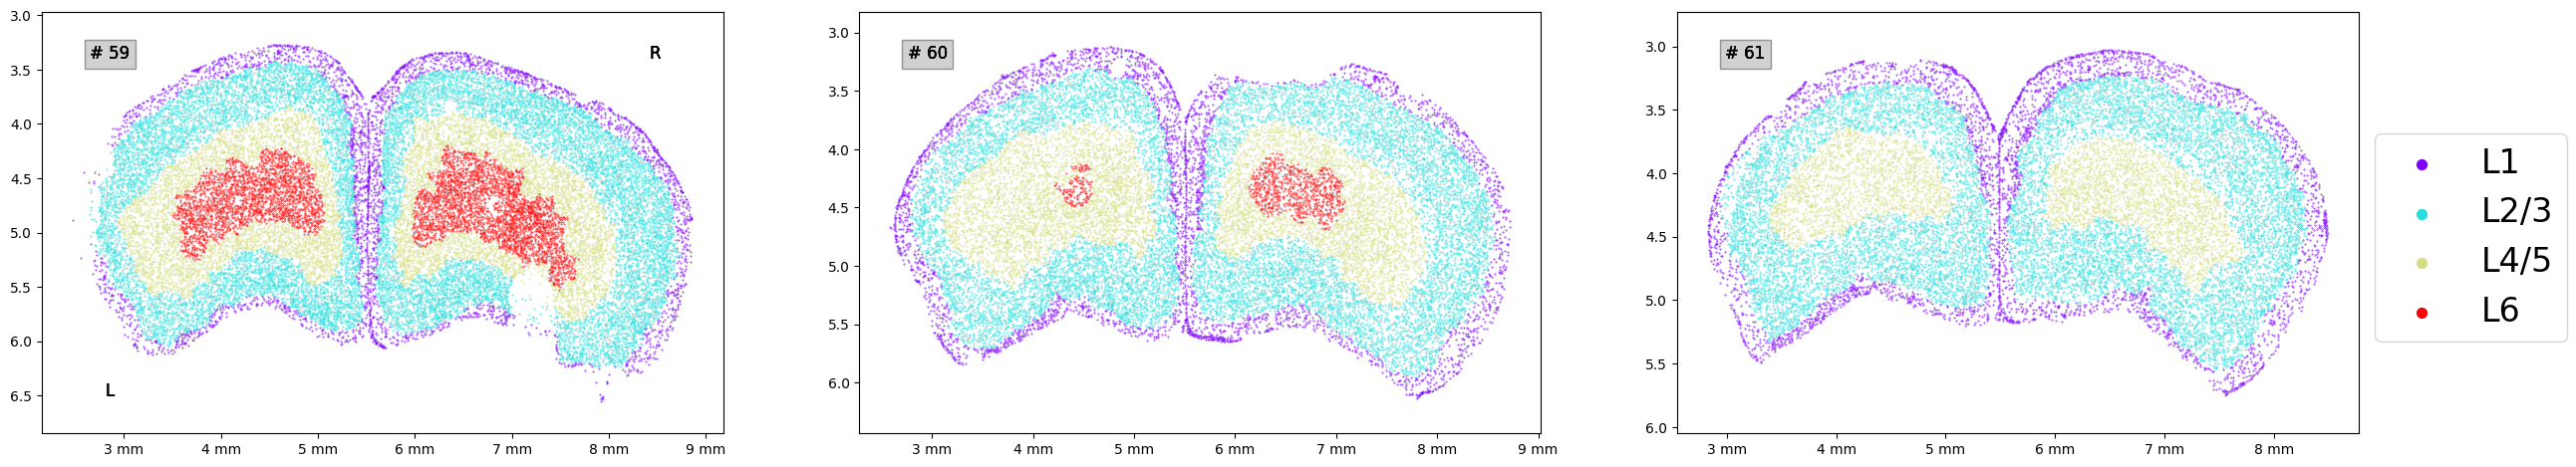

In [49]:
fig, axs = plt.subplots(1,3,figsize=(30,5.5))
# fig.tight_layout()
for t in range(len(sections)):
    section_plot(axs, t,sections[t])